In [5]:
import numpy as np  # Numerical computing ka baap
import pandas as pd  # Data manipulation ki maa
import matplotlib.pyplot as plt  # Basic plotting ka dada
import seaborn as sns  # Beautiful plots ka chacha
import warnings
warnings.filterwarnings('ignore')   # Choti moti warnings ko ignore 

## Load Data_Set

In [6]:
df=pd.read_csv("../data/train.csv")

## 🕵️ Overview Of Data_Se

In [7]:
print('='*79)
print("Overview Of Data_Set")
print('='*79)
print(f"Shape Of Data_set :{df.shape}")
print(f"Rows in data_set :{df.shape[0]}")
print(f"Columns in data_set:{df.shape[1]}")
print(f"Name Of Columns :{df.columns}")

Overview Of Data_Set
Shape Of Data_set :(891, 12)
Rows in data_set :891
Columns in data_set:12
Name Of Columns :Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


## 🔎Data Assessing

In [8]:
print('='*79)
print("Data Assessing")
print('='*79)
# basic state
print("basic state: ")
print(df.describe().T)
# missing values
print("missing values: ")
print(df.isna().sum())
# Duplicates
print("Duplicates: ")
print(df.duplicated().sum())
print("Info:")
print(df.info())

Data Assessing
basic state: 
             count        mean         std   min       25%       50%    75%  \
PassengerId  891.0  446.000000  257.353842  1.00  223.5000  446.0000  668.5   
Survived     891.0    0.383838    0.486592  0.00    0.0000    0.0000    1.0   
Pclass       891.0    2.308642    0.836071  1.00    2.0000    3.0000    3.0   
Age          714.0   29.699118   14.526497  0.42   20.1250   28.0000   38.0   
SibSp        891.0    0.523008    1.102743  0.00    0.0000    0.0000    1.0   
Parch        891.0    0.381594    0.806057  0.00    0.0000    0.0000    0.0   
Fare         891.0   32.204208   49.693429  0.00    7.9104   14.4542   31.0   

                  max  
PassengerId  891.0000  
Survived       1.0000  
Pclass         3.0000  
Age           80.0000  
SibSp          8.0000  
Parch          6.0000  
Fare         512.3292  
missing values: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp          

### Missing values report

In [9]:
def missing_values_report(data):
    missing = data.isnull().sum()
    percentage=(missing/len(data))*100
    report= pd.DataFrame({
        "Missing_Values":missing,
        "Percentage":round(percentage,2)
    })
    return report[report['Missing_Values'] > 0].sort_values('Missing_Values', ascending=False)
print("Missing Repoer")
print(missing_values_report(df))

Missing Repoer
          Missing_Values  Percentage
Cabin                687       77.10
Age                  177       19.87
Embarked               2        0.22


In [10]:
def classify_variables(data):
    """Variables ko categorical aur numerical mein divide karna"""
    cat = []
    num = []
    for col in data.columns:
        if data[col].dtype == 'object':
            cat.append(col)
        elif data[col].dtype in ['int64', 'float64']:
            if data[col].nunique() < 10:  # Agar unique values kam hain toh treat as categorical
                cat.append(col)
            else:
                num.append(col)
    return cat, num


cat_vars, num_vars = classify_variables(df)
print("="*79)
print("🎨 Variable Classification:")
print("="*79)
print("Categorical_Features :\n",cat_vars)
print("Numerical_Features :\n",num_vars)

🎨 Variable Classification:
Categorical_Features :
 ['Survived', 'Pclass', 'Name', 'Sex', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked']
Numerical_Features :
 ['PassengerId', 'Age', 'Fare']


## 📈 BasicDash Board of Assessing

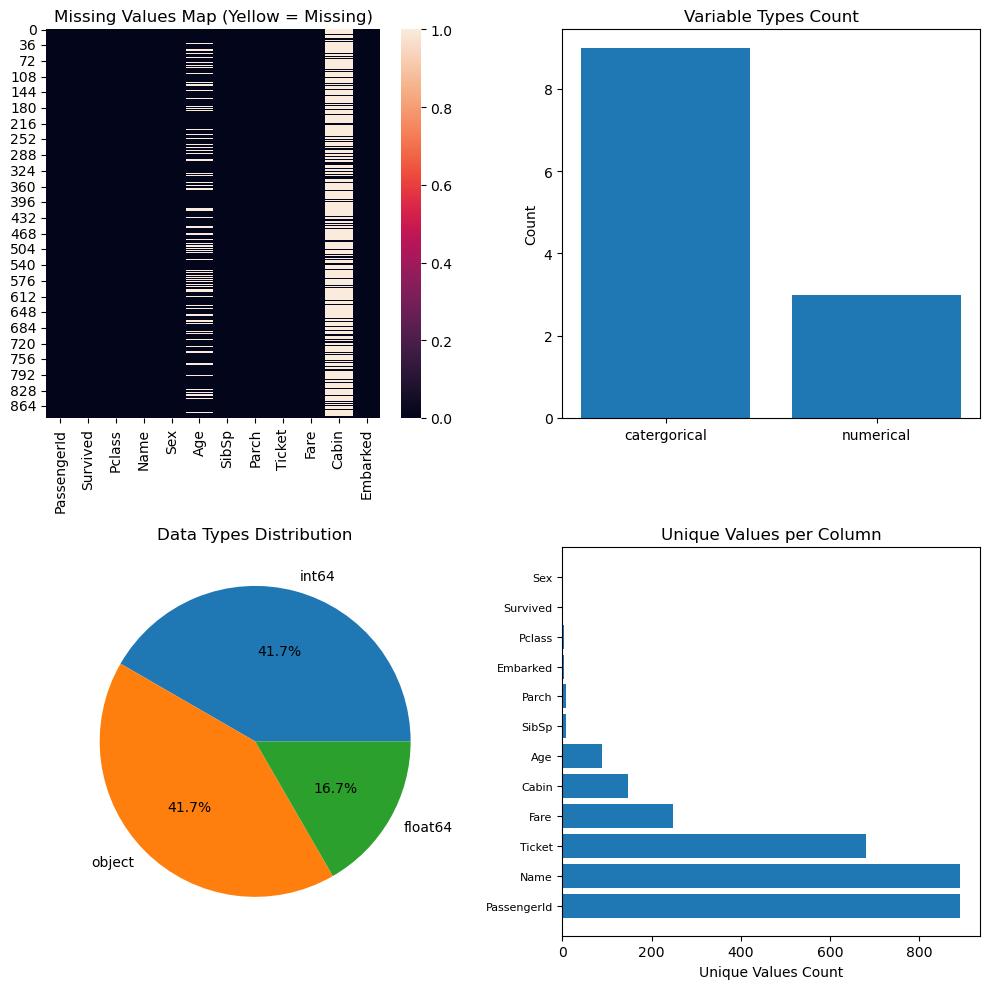

In [11]:
fig , ax =plt.subplots(2,2 ,figsize=(10,10))
# missing Values
sns.heatmap(df.isnull(),ax=ax[0,0])

ax[0,0].set_title("Missing Values Map (Yellow = Missing)")
ax[0,1].bar(['catergorical','numerical'],[len(cat_vars),len(num_vars)])
ax[0,1].set_title('Variable Types Count')
ax[0,1].set_ylabel('Count')



# Data types pie chart
ax[1,0].pie(df.dtypes.value_counts().values,labels=df.dtypes.value_counts().index,autopct='%1.1f%%')
ax[1,0].set_title('Data Types Distribution')

unique_counts = df.nunique().sort_values(ascending=False)

ax[1,1].barh(range(len(unique_counts)),unique_counts.values)
ax[1,1].set_yticks(range(len(unique_counts)))
ax[1,1].set_yticklabels(unique_counts.index, fontsize=8)
ax[1,1].set_title('Unique Values per Column')
ax[1,1].set_xlabel('Unique Values Count')
plt.tight_layout()
plt.show()

## 📊 Data Distributions

In [12]:
print('='*79)
print("Distribution of Numerical columns")
print('='*79)
df[['Age', 'Fare']].describe().T

Distribution of Numerical columns


,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


**KEY INSIGHTS**:

Age:

Mean: 29.7 years (Average passenger age)

Min: 0.4 years 👶

Max: 80 years (Buzurg bnda) 👴

Observation: Standard deviation 14.5.

Fare:

Mean: £32.20

Max: £512.33 (Bhai ne first class ka full ticket liya hoga!)

Distribution of categorical columns


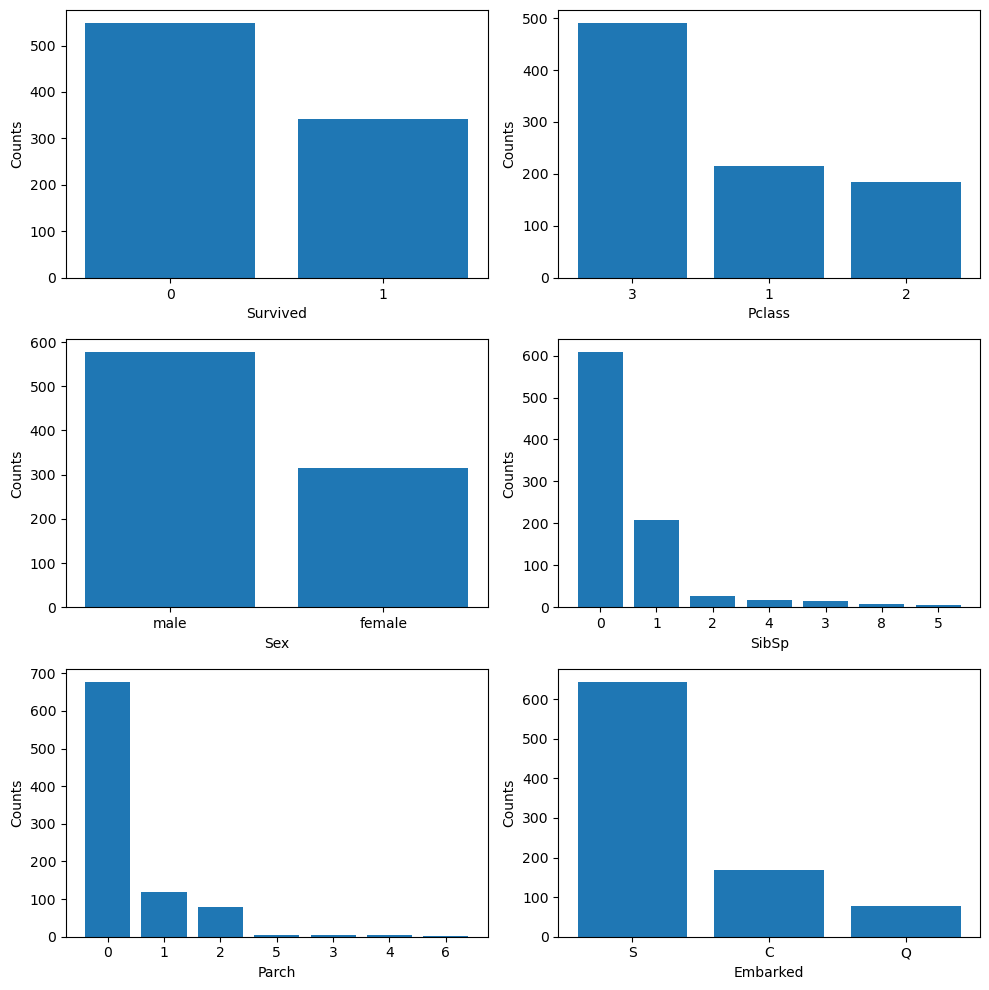

In [13]:
print('='*79)
print("Distribution of categorical columns")
print('='*79)
fig , ax =plt.subplots(3,2,figsize=(10,10))
ax=np.ravel(ax)
cat_col= [ col for col in cat_vars if col not in ['Name', 'Ticket', 'Cabin']]

for i,col in enumerate(cat_col):
    counts=df[col].value_counts()
    ax[i].bar(counts.index.astype(str),df[col].value_counts().values)
    ax[i].set_xlabel(f"{col}")
    ax[i].set_ylabel(f"Counts")
    ax[i].set_xticks(range(len(counts.index)))
    ax[i].set_xticklabels(counts.index)
    # print(df[col].value_counts().to_string())
    # print('-'*30)
plt.tight_layout()
plt.show()

Distribution Dash Board


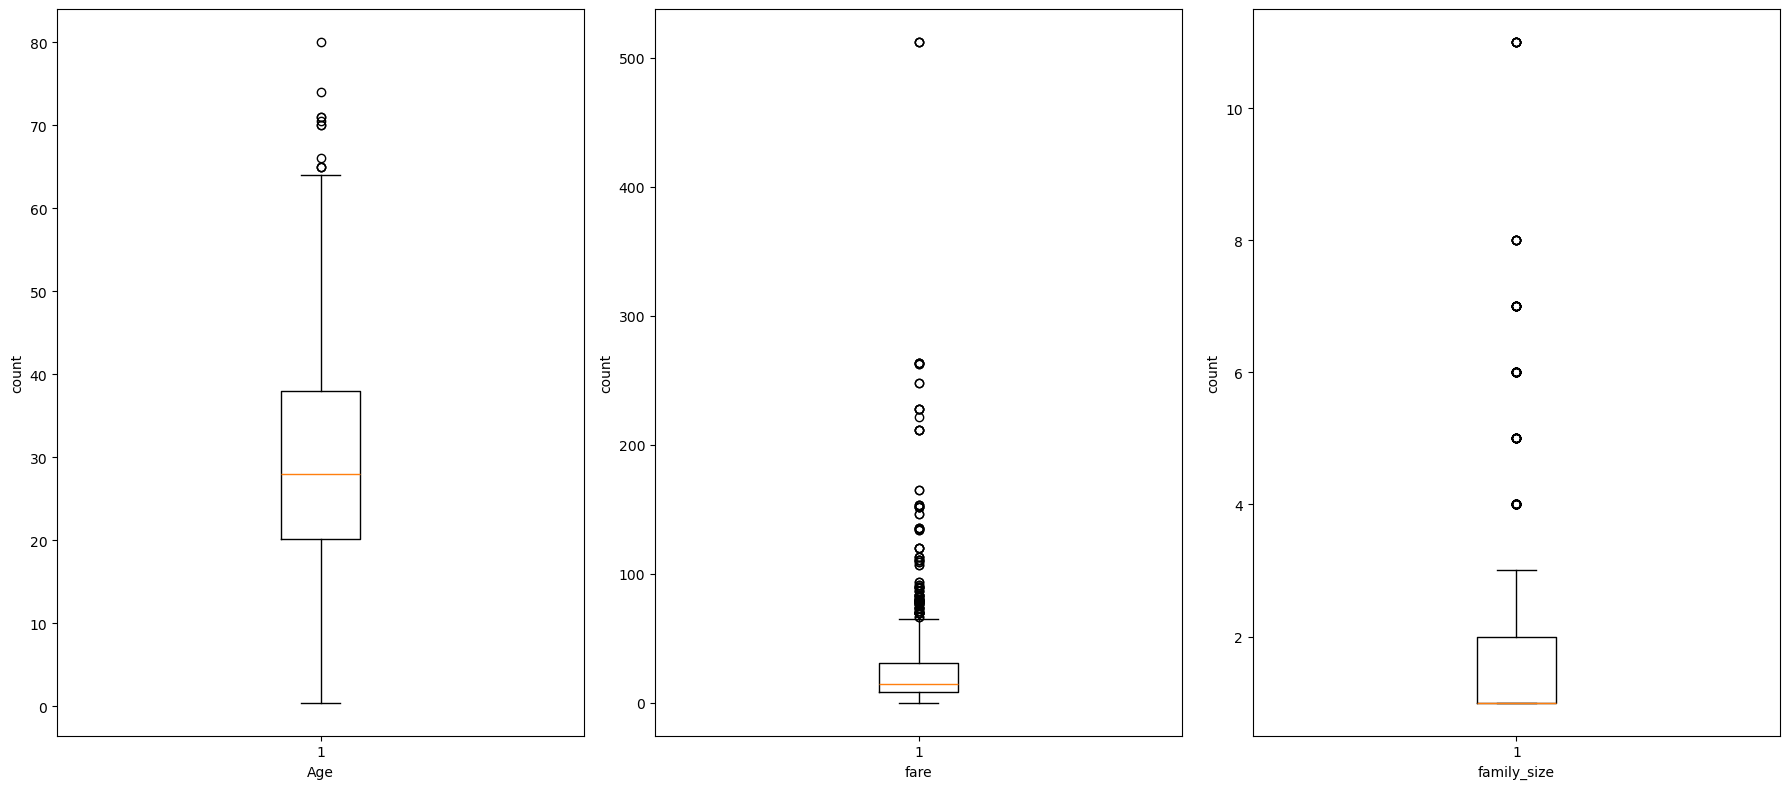

In [14]:
print('='*79)
print("Distribution Dash Board")
print('='*79)
# family size
df['family_size']=df['SibSp']+df['Parch']+1
fig , ax  = plt.subplots(1,3,figsize=(18,8))
# Age 
ax[0].boxplot(df['Age'].dropna()) 
ax[0].set_ylabel("count")
ax[0].set_xlabel("Age")
# Fare
ax[1].boxplot(df['Fare'])
ax[1].set_ylabel("count")
ax[1].set_xlabel("fare")
# family size
ax[2].boxplot(df['family_size'])
ax[2].set_ylabel("count")
ax[2].set_xlabel("family_size")
plt.tight_layout()
plt.show()

Correlation


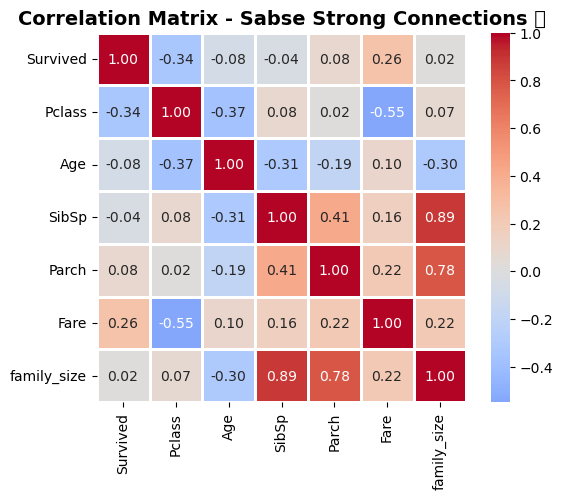

In [15]:
print('='*79)
print("Correlation")
print('='*79)

numerical_df=df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.drop("PassengerId",axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=1, square=True)
plt.title('Correlation Matrix - Sabse Strong Connections 🔗', fontsize=14, fontweight='bold')
plt.show()

**key_insight**:

Fare vs Pclass: -0.55 (Negative correlation: Higher class = Lower fare number, but higher actual fare)

Pclass vs Fare: -0.55 (Higher class number = Lower fare amount) Weak Correlations with Survival:

Fare vs Survived: 0.26 (Higher fare = Better survival chance)

Pclass vs Survived: -0.34 (Higher class = Better survival)

Gender Vs Survival


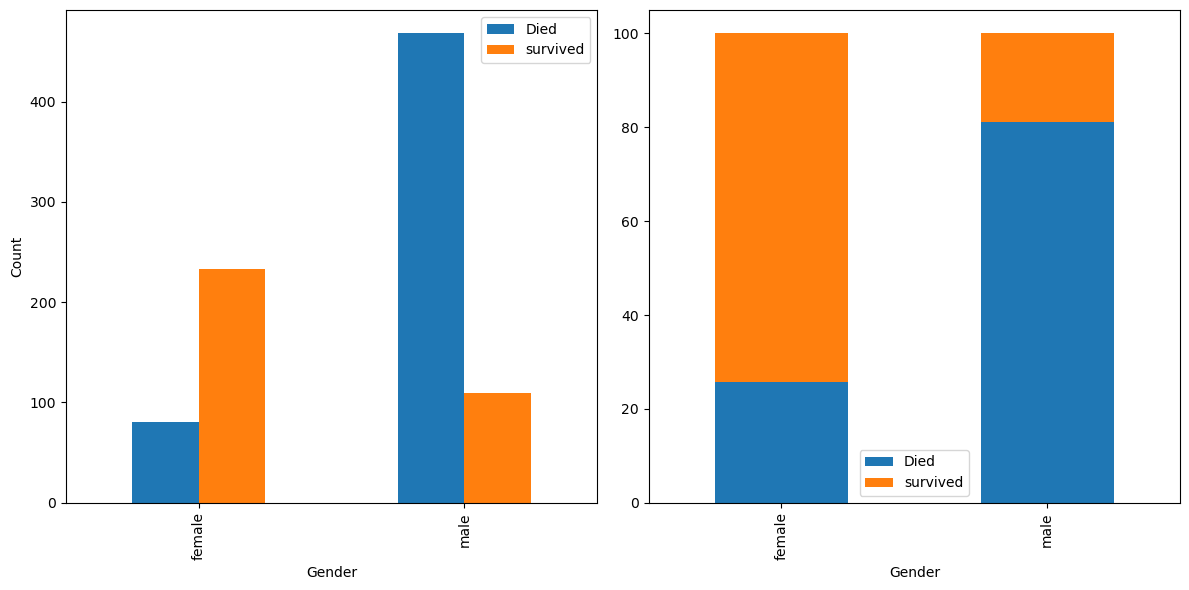

In [16]:
print('='*79)
print("Gender Vs Survival")
print('='*79)
gender_survival = pd.crosstab(df['Sex'], df['Survived'], margins=True)
gender_survival_pct = pd.crosstab(df['Sex'], df['Survived'], normalize='index')*100
fig , ax  = plt.subplots(1,2,figsize=(12,6))
gender_survival.iloc[0:2,0:2].plot(kind='bar',ax=ax[0])
ax[0].set_ylabel("Count")
ax[0].legend(["Died","survived"])
ax[0].set_xlabel("Gender")
gender_survival_pct.plot(kind='bar',ax=ax[1],stacked=True)
ax[1].legend(["Died","survived"])
ax[1].set_xlabel("Gender")
plt.tight_layout()
plt.show()

**Insight**

Female: high chance to survived.

Male: High chance ot die.

💰 CLASS VS SURVIVAL


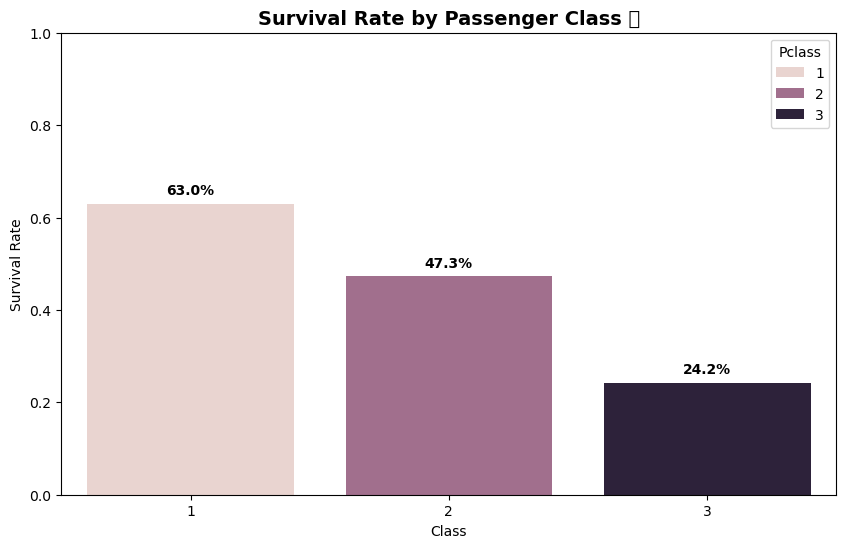

In [17]:
print("💰 CLASS VS SURVIVAL")
print("="*79)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Pclass', y='Survived',hue='Pclass',ci=False)
plt.title('Survival Rate by Passenger Class 💺', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
for i, rate in enumerate(df.groupby('Pclass')['Survived'].mean()):
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontweight='bold')
plt.show()

**Insight**

First Class: 63% survival rate - Royal treatment!

Second Class: 47% survival rate

Third Class: 24% survival rate - Bohat kam!

👨‍👩‍👧‍👦 FAMILY SIZE VS SURVIVAL 
Survival Rate by Family Category (%):
Survived             0      1
family_category              
Large Family     83.87  16.13
Small Family     42.12  57.88
Solo             69.65  30.35


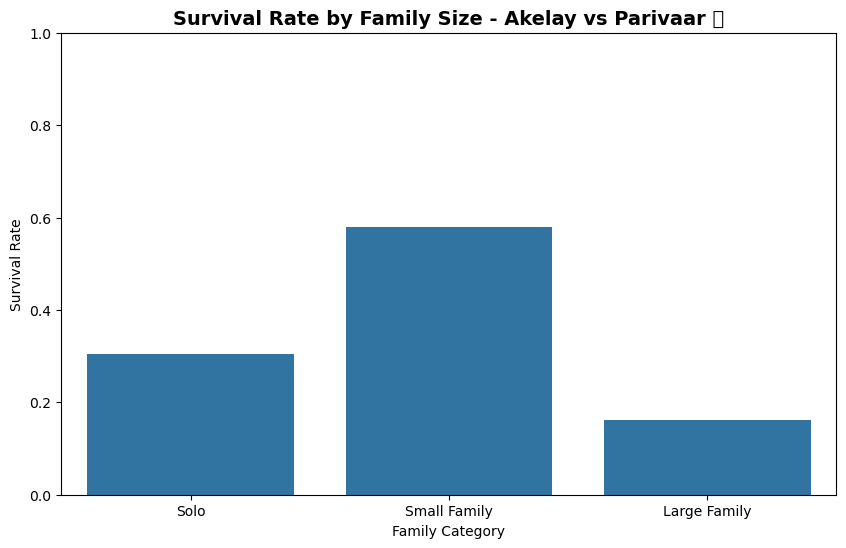

In [18]:
print("👨‍👩‍👧‍👦 FAMILY SIZE VS SURVIVAL ")
print("="*50)

def categorize_family_size(size):
    if size == 1:
        return 'Solo'
    elif size <= 4:
        return 'Small Family'
    else:
        return 'Large Family'
df['family_category']=df['family_size'].apply(categorize_family_size)

family_survival = pd.crosstab(df['family_category'], df['Survived'], normalize='index') * 100
print("Survival Rate by Family Category (%):")
print(family_survival.round(2))

plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='family_category', y='Survived', 
            order=['Solo', 'Small Family', 'Large Family'],ci=False)
plt.title('Survival Rate by Family Size - Akelay vs Parivaar 🤔', fontsize=14, fontweight='bold')
plt.xlabel('Family Category')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()


**🎯Conclusion**

Age: If you are a child you have higher chance of survival.

Gender: Females has more higher chance of survival.

## implementing model

In [38]:

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score,confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.svm import SVC
import joblib

In [20]:
x=df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin','family_category','SibSp','Parch'],axis=1)
y=df['Survived']
num_feature=['Age','Fare']
cat_feature=['Sex','Embarked']

In [21]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
pip_num=Pipeline([('impute',SimpleImputer()),('scale',StandardScaler())])
pip_cat=Pipeline([('impute_cat',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(drop='first',sparse_output=False))])
preprocessing=ColumnTransformer([('cat_processing',pip_cat,cat_feature),('num_clean',pip_num,num_feature)],remainder='passthrough')
model_lr=Pipeline([('preprocessing',preprocessing),('lr',LogisticRegression())])

In [28]:
model_lr.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_processing', ...), ('num_clean', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred=model_lr.predict(x_test)
print("f1_score:", f1_score(y_test,y_pred))
print("Counfusion matrics:", confusion_matrix(y_test,y_pred))
print('Accuracy Score :',accuracy_score(y_test,y_pred))

In [ ]:
joblib.dump(model_lr, '../models/titanic_model.pkl')
print("Model saved.")

Model saved.


In [ ]:
model_dt=Pipeline([('cleaning',preprocessing),('dt',DecisionTreeClassifier())])
model_rf=Pipeline([('cleaning',preprocessing),('rf',RandomForestClassifier())])
model_svc=Pipeline([('cleaning',preprocessing),('svc',SVC())])

In [33]:
dt_cv=cross_val_score(model_dt,x_train,y_train,cv=5,scoring='f1')
print("Descision tree f1 score ",dt_cv.mean())

Descision tree f1 score  0.6920891957589206


In [35]:
rf_cv=cross_val_score(model_rf,x_train,y_train,cv=5,scoring='f1')
print("random forest tree f1 score ",rf_cv.mean())

random forest tree f1 score  0.7237700693708392


In [43]:
svc_cv=cross_val_score(model_svc,x_train,y_train,cv=5,scoring='f1')
print("random forest tree f1 score ",svc_cv.mean())

random forest tree f1 score  0.7521989212765543


In [50]:
param_grid_logreg = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['saga']   # saga supports both l1 and l2
}
grid_logreg = GridSearchCV(
    model_lr,
    param_grid_logreg,
    cv=5,
    scoring='f1',      # or 'f1' / 'roc_auc' for classification
    n_jobs=-1,
    verbose=1
)
grid_logreg.fit(x_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'lr__C': [0.01, 0.1, ...], 'lr__penalty': ['l1', 'l2'], 'lr__solver': ['saga']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat_processing', ...), ('num_clean', ...)]"


In [51]:
print("Best C:", grid_logreg.best_params_)
print("Best CV score:", grid_logreg.best_score_)

Best C: {'lr__C': 10, 'lr__penalty': 'l1', 'lr__solver': 'saga'}
Best CV score: 0.7146245989528748


In [52]:
param_grid_svc = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf']
}

grid_svc = GridSearchCV(
    model_svc,
    param_grid_svc,
    cv=5,
    scoring='accuracy',   # or 'f1', 'roc_auc' depending on your metric
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(x_train, y_train)

print("Best params:", grid_svc.best_params_)
print("Best CV score:", grid_svc.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svc__C': 1, 'svc__kernel': 'rbf'}
Best CV score: 0.8243770314192849


In [63]:
from sklearn.ensemble import VotingClassifier
estematers=[('svc1',SVC(C=10, kernel='rbf')),('svc2',SVC(C=1,kernel='rbf')),('svc3',SVC(C=1,kernel='linear'))]

model_ens=Pipeline([('cleaning',preprocessing),('ens',VotingClassifier(estimators=estematers))])

In [64]:
vc_x=cross_val_score(model_ens,x_train,y_train,cv=5,scoring='f1')
print(vc_x.mean())

0.7528116178403284
